# 01 — Constant Velocity Intercept

The previous notebook showed that aiming at the target's current position always misses. This notebook finds the correct aim point.

The key insight: if the target moves at constant speed and heading, you can predict exactly where it will be at any future time `t`. The intercept time is the `t` at which the distance from your launch site to that future position equals `shooter_speed × t` — the distance your interceptor can cover in the same time.

Finding that `t` is the whole problem. Once you have it, everything else follows directly.

In [1]:
import math

def compute_bearing(p1, p2):
    lon1, lat1 = math.radians(p1[0]), math.radians(p1[1])
    lon2, lat2 = math.radians(p2[0]), math.radians(p2[1])
    d_lon = lon2 - lon1
    x = math.sin(d_lon) * math.cos(lat2)
    y = math.cos(lat1) * math.sin(lat2) - math.sin(lat1) * math.cos(lat2) * math.cos(d_lon)
    return (math.degrees(math.atan2(x, y)) + 360) % 360

def haversine_km(p1, p2):
    R = 6371.0
    lon1, lat1 = math.radians(p1[0]), math.radians(p1[1])
    lon2, lat2 = math.radians(p2[0]), math.radians(p2[1])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

def destination_point(origin, bearing_deg, distance_km):
    R = 6371.0
    d   = distance_km / R
    brg = math.radians(bearing_deg)
    lat1 = math.radians(origin[1])
    lon1 = math.radians(origin[0])
    lat2 = math.asin(math.sin(lat1)*math.cos(d) + math.cos(lat1)*math.sin(d)*math.cos(brg))
    lon2 = lon1 + math.atan2(math.sin(brg)*math.sin(d)*math.cos(lat1),
                              math.cos(d) - math.sin(lat1)*math.sin(lat2))
    return [math.degrees(lon2), math.degrees(lat2)]

# Scenario from Notebook 00
shooter_pos    = [-98.49, 33.91]
target_pos     = [-101.0, 36.5]
target_speed   = 300
target_heading = 135
shooter_speed  = 600

print("Scenario loaded.")

Scenario loaded.


## 1. The Model and Its Assumptions

Before writing a single line of code, be explicit about what you are and are not modeling.

**Assumptions:**
- Target moves at **constant speed** and **constant heading** — no maneuvers
- Interceptor travels at **constant speed** in a **straight line** to its aim point
- Earth is treated as a sphere (Haversine for distances, `destination_point` for positions)
- No atmospheric effects, no guidance corrections in flight

**What this gives you:** a clean closed-form search for the intercept time. In a real system these assumptions break quickly. In this module they let you understand the geometry before adding complexity.

**The intercept condition:**

At time `t`, the target is at:
```text
target_at_t = destination_point(target_pos, target_heading, target_speed × t)
```

The interceptor can reach any point within radius `shooter_speed × t`. The intercept exists when:
```text
haversine_km(shooter_pos, target_at_t)  =  shooter_speed × t
```

This is one equation in one unknown (`t`). It has no clean algebraic solution on a sphere, but it is monotone enough that a binary search converges in milliseconds.

## 2. Finding the Intercept Time

The function `f(t) = haversine_km(shooter, target_at_t) - shooter_speed × t` starts positive when `t` is small (target is far, interceptor hasn't had time to reach it) and goes negative when `t` is large (interceptor has more than enough range). The zero crossing is the intercept time.

Binary search works because `f(t)` is continuous and crosses zero exactly once (for feasible scenarios). Set a lower bound of `t=0` and an upper bound large enough that the interceptor can definitely reach the target, then halve the interval until the solution is precise.

In [2]:
def find_intercept_time(shooter_pos, target_pos, target_heading,
                        target_speed, shooter_speed,
                        t_max=10.0, tol=1e-6):
    """
    Find the time t (hours) at which the interceptor can reach the target.

    Uses binary search on:
        f(t) = haversine_km(shooter, target_at_t) - shooter_speed * t

    Returns None if no intercept is possible within t_max hours.
    """
    def f(t):
        future = destination_point(target_pos, target_heading, target_speed * t)
        return haversine_km(shooter_pos, future) - shooter_speed * t

    # Check feasibility: f must go negative somewhere before t_max
    if f(t_max) > 0:
        return None   # interceptor can never catch the target

    lo, hi = 0.0, t_max
    for _ in range(60):   # 60 halvings → precision < 1e-12
        mid = (lo + hi) / 2
        if f(mid) > 0:
            lo = mid
        else:
            hi = mid
        if (hi - lo) < tol:
            break

    return (lo + hi) / 2


# Test on the module scenario
t_intercept = find_intercept_time(
    shooter_pos, target_pos, target_heading, target_speed, shooter_speed
)

if t_intercept is None:
    print("No intercept possible.")
else:
    intercept_point = destination_point(target_pos, target_heading, target_speed * t_intercept)
    fire_bearing    = compute_bearing(shooter_pos, intercept_point)
    dist_to_intercept = haversine_km(shooter_pos, intercept_point)

    print(f"Intercept time:    {t_intercept:.4f} h  ({t_intercept*60:.1f} min)")
    print(f"Intercept point:   [{intercept_point[0]:.4f}, {intercept_point[1]:.4f}]")
    print(f"Fire bearing:      {fire_bearing:.2f}°")
    print(f"Distance to fly:   {dist_to_intercept:.1f} km")
    print()
    # Verification
    interceptor_dist = shooter_speed * t_intercept
    print(f"Interceptor range at t: {interceptor_dist:.1f} km")
    print(f"Residual (should ≈ 0):  {abs(dist_to_intercept - interceptor_dist):.6f} km")

Intercept time:    0.4092 h  (24.6 min)
Intercept point:   [-100.0385, 35.7155]
Fire bearing:      325.29°
Distance to fly:   245.5 km

Interceptor range at t: 245.5 km
Residual (should ≈ 0):  0.000134 km


## 3. The Full `compute_intercept` Function

Wrap everything into one clean function that returns all three outputs: the intercept point, the fire bearing, and the time of flight. This is the function the rest of the module will call.

In [3]:
def compute_intercept(shooter_pos, target_pos, target_heading,
                      target_speed, shooter_speed, t_max=10.0):
    """
    Compute the constant-velocity intercept solution.

    Parameters
    ----------
    shooter_pos    : [lon, lat] — launch site
    target_pos     : [lon, lat] — target's current position
    target_heading : float, degrees — target's constant bearing
    target_speed   : float, km/h
    shooter_speed  : float, km/h
    t_max          : float, hours — search horizon

    Returns
    -------
    dict with keys:
        intercept_point  : [lon, lat]
        fire_bearing     : float, degrees
        time_of_flight   : float, hours
        distance_km      : float
    or None if no intercept is possible within t_max.
    """
    t = find_intercept_time(shooter_pos, target_pos, target_heading,
                            target_speed, shooter_speed, t_max)
    if t is None:
        return None

    intercept_point = destination_point(target_pos, target_heading, target_speed * t)
    return {
        "intercept_point": intercept_point,
        "fire_bearing":    compute_bearing(shooter_pos, intercept_point),
        "time_of_flight":  t,
        "distance_km":     haversine_km(shooter_pos, intercept_point),
    }


# Run and display
result = compute_intercept(
    shooter_pos, target_pos, target_heading, target_speed, shooter_speed
)

if result is None:
    print("No intercept possible.")
else:
    print("=== Intercept Solution ===")
    for k, v in result.items():
        if isinstance(v, float):
            print(f"  {k:<18} {v:.4f}")
        else:
            print(f"  {k:<18} {v}")

=== Intercept Solution ===
  intercept_point    [-100.03850350490927, 35.715451841129116]
  fire_bearing       325.2870
  time_of_flight     0.4092
  distance_km        245.5279


## 4. Comparing Naive vs. Intercept Solutions

The intercept solution fires at a *different bearing* than the naive solution and arrives at a *different point* — one where the target will actually be. The table below puts both side by side so the difference is clear.

In [4]:
# Naive solution
naive_bearing     = compute_bearing(shooter_pos, target_pos)
naive_dist        = haversine_km(shooter_pos, target_pos)
naive_tof         = naive_dist / shooter_speed
naive_aim_point   = destination_point(shooter_pos, naive_bearing, naive_dist)
target_at_naive   = destination_point(target_pos, target_heading, target_speed * naive_tof)
naive_miss        = haversine_km(naive_aim_point, target_at_naive)

print(f"{'':30} {'Naive':>14}  {'Intercept':>12}")
print("-" * 60)
print(f"{'Fire bearing':<30} {naive_bearing:>13.2f}°  {result['fire_bearing']:>11.2f}°")
print(f"{'Time of flight (h)':<30} {naive_tof:>13.4f}   {result['time_of_flight']:>11.4f}")
print(f"{'Time of flight (min)':<30} {naive_tof*60:>13.1f}   {result['time_of_flight']*60:>11.1f}")
print(f"{'Distance flown (km)':<30} {naive_dist:>13.1f}   {result['distance_km']:>11.1f}")
print(f"{'Miss distance (km)':<30} {naive_miss:>13.1f}   {'0.000':>12}")

                                        Naive     Intercept
------------------------------------------------------------
Fire bearing                          322.34°       325.29°
Time of flight (h)                    0.6122        0.4092
Time of flight (min)                    36.7          24.6
Distance flown (km)                    367.3         245.5
Miss distance (km)                     183.7          0.000


## 5. Visualizing the Solution

Three paths on one map tells the full story:
- **Target path** — where it goes from t=0 onward (blue dashed)
- **Naive fire line** — the wrong direction (gray)
- **Intercept fire line** — the correct direction (red), landing exactly on the target path

In [5]:
from ipyleaflet import Map, GeoJSON

tof   = result["time_of_flight"]
ipt   = result["intercept_point"]

# Target path (extend past intercept for context)
target_path_coords = [
    destination_point(target_pos, target_heading, target_speed * t / 20)
    for t in range(0, 25)
]

# Build feature collections
def fc(features): return {"type": "FeatureCollection", "features": features}
def line(coords, props={}): return {"type":"Feature","geometry":{"type":"LineString","coordinates":coords},"properties":props}
def point(coord, props={}): return {"type":"Feature","geometry":{"type":"Point","coordinates":coord},"properties":props}

m = Map(center=(35.5, -99.5), zoom=6)

# Target path
m.add(GeoJSON(data=fc([line(target_path_coords)]),
              style={"color": "#457b9d", "weight": 2, "dashArray": "6"}))

# Naive fire line (gray)
m.add(GeoJSON(data=fc([line([shooter_pos, naive_aim_point])]),
              style={"color": "#aaaaaa", "weight": 1.5, "dashArray": "4"}))

# Intercept fire line (red)
m.add(GeoJSON(data=fc([line([shooter_pos, ipt])]),
              style={"color": "#e63946", "weight": 2}))

# Key points
m.add(GeoJSON(data=fc([point(shooter_pos)]),
              point_style={"radius": 7, "color": "#e63946", "fillOpacity": 1.0}))
m.add(GeoJSON(data=fc([point(target_pos)]),
              point_style={"radius": 7, "color": "#457b9d", "fillOpacity": 1.0}))
m.add(GeoJSON(data=fc([point(ipt)]),
              point_style={"radius": 7, "color": "#2a9d8f", "fillOpacity": 1.0}))
m.add(GeoJSON(data=fc([point(naive_aim_point)]),
              point_style={"radius": 6, "color": "#aaaaaa", "fillOpacity": 0.8}))

print(f"Red dot  = intercept point  ({ipt[0]:.3f}, {ipt[1]:.3f})")
print(f"Blue dot = target at t=0")
print(f"Gray dot = naive aim point (miss = {naive_miss:.1f} km)")
m

Red dot  = intercept point  (-100.039, 35.715)
Blue dot = target at t=0
Gray dot = naive aim point (miss = 183.7 km)


Map(center=[35.5, -99.5], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

The red line hits the target path exactly. The gray line misses by the amount computed in Notebook 00.

---

## Exercise A — Vary the Speed Ratio

Run `compute_intercept` for each speed ratio below, keeping the scenario geometry constant. Print the fire bearing, time of flight, and intercept point for each. At what ratio does the function return `None`?

```python
shooter_speeds = [150, 200, 250, 300, 350, 400, 600, 900]
# target_speed stays at 300 km/h
```

In [6]:
shooter_speeds = [150, 200, 250, 300, 350, 400, 600, 900]

print(f"{'Shooter spd':>12}  {'Ratio':>7}  {'TOF (min)':>10}  {'Fire brg':>10}  {'Result':>10}")
print("-" * 58)

for spd in shooter_speeds:
    
    r = compute_intercept(
        shooter_pos,
        target_pos,
        target_heading,
        target_speed,
        spd
    )
    
    ratio = spd / target_speed
    
    if r is None:
        print(f"{spd:>10} km/h  {ratio:>6.2f}×  {'—':>10}  {'—':>10}  NO INTERCEPT")
    
    else:
        print(f"{spd:>10} km/h  "
              f"{ratio:>6.2f}×  "
              f"{r['time_of_flight']*60:>9.1f}m  "
              f"{r['fire_bearing']:>9.2f}°  ok")
        
        print(f"    Intercept point: "
              f"[{r['intercept_point'][0]:.4f}, "
              f"{r['intercept_point'][1]:.4f}]")

 Shooter spd    Ratio   TOF (min)    Fire brg      Result
----------------------------------------------------------
       150 km/h    0.50×           —           —  NO INTERCEPT
       200 km/h    0.67×           —           —  NO INTERCEPT
       250 km/h    0.83×           —           —  NO INTERCEPT
       300 km/h    1.00×       36.9m     328.24°  ok
    Intercept point: [-99.5611, 35.3172]
       350 km/h    1.17×       34.1m     327.39°  ok
    Intercept point: [-99.6713, 35.4096]
       400 km/h    1.33×       31.6m     326.76°  ok
    Intercept point: [-99.7657, 35.4886]
       600 km/h    2.00×       24.6m     325.29°  ok
    Intercept point: [-100.0385, 35.7155]
       900 km/h    3.00×       18.4m     324.31°  ok
    Intercept point: [-100.2777, 35.9128]


## Exercise B — Vary the Target Heading

Keep `shooter_speed = 600` and `target_speed = 300`. Sweep `target_heading` from `0°` to `350°` in `10°` steps. For each heading, compute the intercept time and fire bearing (or flag as impossible).

Plot the time of flight vs. target heading on a polar chart or a line chart. At what headings is intercept fastest? Slowest? Impossible?

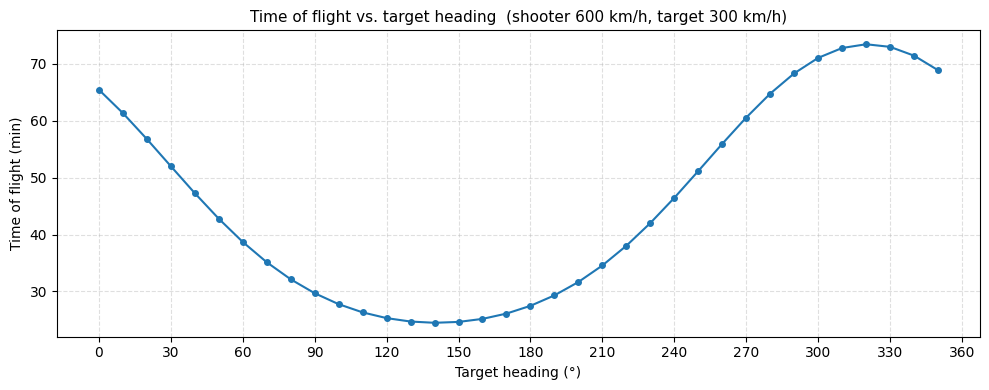

Fastest intercept heading(s): [140]
Fastest time: 24.5 min
Slowest intercept heading(s): [320]
Slowest time: 73.5 min
Impossible heading(s): None


In [7]:
import matplotlib.pyplot as plt

headings = list(range(0, 360, 10))
tofs = []

for h in headings:
    r = compute_intercept(shooter_pos, target_pos, h, target_speed, 600)
    tofs.append(r["time_of_flight"] * 60 if r else None)

fig, ax = plt.subplots(figsize=(10, 4))
ax.set_title("Time of flight vs. target heading  (shooter 600 km/h, target 300 km/h)", fontsize=11)
ax.set_xlabel("Target heading (°)")
ax.set_ylabel("Time of flight (min)")
ax.set_xticks(range(0, 361, 30))

valid_h = [h for h, t in zip(headings, tofs) if t is not None]
valid_t = [t for t in tofs if t is not None]
invalid_h = [h for h, t in zip(headings, tofs) if t is None]

ax.plot(valid_h, valid_t, "-o", markersize=4, linewidth=1.5)

for h in invalid_h:
    ax.axvline(h, linewidth=0.8, linestyle="--", alpha=0.6)

ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Summary
min_t = min(valid_t)
max_t = max(valid_t)

fastest_headings = [h for h, t in zip(valid_h, valid_t) if t == min_t]
slowest_headings = [h for h, t in zip(valid_h, valid_t) if t == max_t]

print("Fastest intercept heading(s):", fastest_headings)
print(f"Fastest time: {min_t:.1f} min")

print("Slowest intercept heading(s):", slowest_headings)
print(f"Slowest time: {max_t:.1f} min")

if invalid_h:
    print("Impossible heading(s):", invalid_h)
else:
    print("Impossible heading(s): None")

## Exercise C — Multiple Incoming Targets

Given the three targets below, each with different positions, speeds, and headings, compute the intercept solution for each. Print a ranked table sorted by time of flight (soonest threat first).

```python
targets = [
    {"pos": [-103.0, 37.0], "heading": 135, "speed": 250},
    {"pos": [-96.0,  38.0], "heading": 210, "speed": 400},
    {"pos": [-100.5, 35.0], "heading":  90, "speed": 180},
]
shooter_speed = 600
```

In [8]:
targets = [
    {"pos": [-103.0, 37.0], "heading": 135, "speed": 250},
    {"pos": [-96.0,  38.0], "heading": 210, "speed": 400},
    {"pos": [-100.5, 35.0], "heading":  90, "speed": 180},
]

shooter_speed = 600

results = []

for i, target in enumerate(targets, start=1):
    r = compute_intercept(
        shooter_pos,
        target["pos"],
        target["heading"],
        target["speed"],
        shooter_speed
    )
    
    if r is not None:
        results.append({
            "target": i,
            "time_min": r["time_of_flight"] * 60,
            "fire_bearing": r["fire_bearing"],
            "intercept_point": r["intercept_point"],
            "distance_km": r["distance_km"]
        })

# Sort by soonest time of flight
results.sort(key=lambda x: x["time_min"])

print(f"{'Rank':<6} {'Target':<8} {'TOF (min)':>10} {'Fire brg':>10} {'Distance':>10} {'Intercept point':>28}")
print("-" * 82)

for rank, r in enumerate(results, start=1):
    lon, lat = r["intercept_point"]
    
    print(f"{rank:<6} "
          f"{r['target']:<8} "
          f"{r['time_min']:>10.1f} "
          f"{r['fire_bearing']:>9.2f}° "
          f"{r['distance_km']:>9.1f} km "
          f"[{lon:.4f}, {lat:.4f}]")

Rank   Target    TOF (min)   Fire brg   Distance              Intercept point
----------------------------------------------------------------------------------
1      3              17.8    313.24°     178.0 km [-99.9137, 34.9986]
2      2              30.4     23.49°     304.5 km [-97.1340, 36.4137]
3      1              37.8    308.75°     377.6 km [-101.7633, 35.9929]


---

## Check Your Understanding

A student notices that `find_intercept_time` uses binary search with a fixed `t_max=10.0` hours. They ask: *"What if the intercept actually happens at t = 10.5 hours? Won't the function return `None` incorrectly?"*

**Question:** They are right that this edge case exists. How would you modify the function to handle it robustly, and what is the practical trade-off of simply increasing `t_max` to a very large number?

```python
# your answer here
```


---

Yes, the student is correct. If the true intercept happens after `t_max`, the function could incorrectly return `None` because it never searches far enough in time.

A more robust solution would be to dynamically increase the search interval until either:
- an intercept is found (`f(t)` becomes negative), or
- a maximum safety limit is reached.

For example, the function could repeatedly double `t_max`:

```python
while f(t_max) > 0:
    t_max *= 2

## Next

In [02 — Iterative Pursuit](./02-Iterative_Pursuit.ipynb), we implement pure pursuit — an interceptor that re-aims at the target's current position every time step — and compare its curved path against the predictive intercept solution.